# DataCo Supply Chain — EDA

In [ ]:
# %pip install polars matplotlib --quiet

In [1]:
import sqlite3
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 100,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.titlesize": 13, "axes.titleweight": "bold",
})

conn = sqlite3.connect("data/dataco.db")
df = pl.read_database("SELECT * FROM supply_chain", conn)
conn.close()

print(f"Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Period : {df['order_date'].min()} to {df['order_date'].max()}")
df.head(3)

Shape  : 180,519 rows x 54 columns
Period : 2015-01-01 00:00:00 to 2018-01-31 23:38:00


payment_type,days_shipping_real,days_shipping_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_email,customer_fname,customer_id,customer_lname,customer_password,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,latitude,longitude,market,order_city,order_country,order_customer_id,order_date,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,order_zipcode,product_card_id,product_category_id,product_description,product_image,product_name,product_price,product_status,shipping_date,shipping_mode,shipping_delay_days
str,f64,f64,f64,f64,str,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,f64,null,str,str,f64,f64,str,str,i64
"""DEBIT""",3.0,4.0,91.25,314.640015,"""Advance shipping""",0.0,73.0,"""Sporting Goods""","""Caguas""","""Puerto Rico""","""XXXXXXXXX""","""Cally""",20755.0,"""Holloway""","""XXXXXXXXX""","""Consumer""","""PR""","""5365 Noble Nectar Island""","""725""",2.0,"""Fitness""",18.251453,-66.037056,"""Pacific Asia""","""Bekasi""","""Indonesia""",20755.0,"""2018-01-31 22:56:00""",77202.0,1360.0,13.11,0.04,180517.0,327.75,0.29,1.0,327.75,314.640015,91.25,"""Southeast Asia""","""Java Occidental""","""COMPLETE""",null,1360.0,73.0,null,"""http://images.acmesports.sport…","""Smart watch""",327.75,0.0,"""2018-02-03 22:56:00""","""Standard Class""",-1
"""TRANSFER""",5.0,4.0,-249.089996,311.359985,"""Late delivery""",1.0,73.0,"""Sporting Goods""","""Caguas""","""Puerto Rico""","""XXXXXXXXX""","""Irene""",19492.0,"""Luna""","""XXXXXXXXX""","""Consumer""","""PR""","""2679 Rustic Loop""","""725""",2.0,"""Fitness""",18.279451,-66.037064,"""Pacific Asia""","""Bikaner""","""India""",19492.0,"""2018-01-13 12:27:00""",75939.0,1360.0,16.389999,0.05,179254.0,327.75,-0.8,1.0,327.75,311.359985,-249.089996,"""South Asia""","""Rajastán""","""PENDING""",null,1360.0,73.0,null,"""http://images.acmesports.sport…","""Smart watch""",327.75,0.0,"""2018-01-18 12:27:00""","""Standard Class""",1
"""CASH""",4.0,4.0,-247.779999,309.720001,"""Shipping on time""",0.0,73.0,"""Sporting Goods""","""San Jose""","""EE. UU.""","""XXXXXXXXX""","""Gillian""",19491.0,"""Maldonado""","""XXXXXXXXX""","""Consumer""","""CA""","""8510 Round Bear Gate""","""95125""",2.0,"""Fitness""",37.292233,-121.881279,"""Pacific Asia""","""Bikaner""","""India""",19491.0,"""2018-01-13 12:06:00""",75938.0,1360.0,18.030001,0.06,179253.0,327.75,-0.8,1.0,327.75,309.720001,-247.779999,"""South Asia""","""Rajastán""","""CLOSED""",null,1360.0,73.0,null,"""http://images.acmesports.sport…","""Smart watch""",327.75,0.0,"""2018-01-17 12:06:00""","""Standard Class""",0


## 1. Schema — Column Names & Data Types

In [2]:
numeric_cols = [c for c in df.columns if df[c].dtype.is_numeric()]
string_cols  = [c for c in df.columns if df[c].dtype == pl.String or df[c].dtype == pl.Utf8]
other_cols   = [c for c in df.columns if c not in numeric_cols + string_cols]

print(f"Numeric : {len(numeric_cols)} cols  |  String : {len(string_cols)} cols  |  Other : {len(other_cols)} cols")
print()
for col in df.columns:
    print(f"  {col:<35} {str(df[col].dtype):<20}")

Numeric : 27 cols  |  String : 26 cols  |  Other : 1 cols

  payment_type                        String              
  days_shipping_real                  Float64             
  days_shipping_scheduled             Float64             
  benefit_per_order                   Float64             
  sales_per_customer                  Float64             
  delivery_status                     String              
  late_delivery_risk                  Float64             
  category_id                         Float64             
  category_name                       String              
  customer_city                       String              
  customer_country                    String              
  customer_email                      String              
  customer_fname                      String              
  customer_id                         Float64             
  customer_lname                      String              
  customer_password                   String            

## 2. Column Profiles

### 2a. Numeric Columns — describe()

In [3]:
key_numeric = [
    "sales", "order_profit_per_order", "order_item_profit_ratio",
    "order_item_discount_rate", "order_item_quantity",
    "days_shipping_real", "days_shipping_scheduled", "shipping_delay_days",
    "order_item_product_price", "benefit_per_order",
]
pl.Config.set_tbl_rows(20)
df.select(key_numeric).describe()

statistic,sales,order_profit_per_order,order_item_profit_ratio,order_item_discount_rate,order_item_quantity,days_shipping_real,days_shipping_scheduled,shipping_delay_days,order_item_product_price,benefit_per_order
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",180519.0,180519.0,180519.0,180519.0,180519.0,180519.0,180519.0,180519.0,180519.0,180519.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",203.772096,21.974989,0.120647,0.101668,2.127638,3.497654,2.931847,0.565807,141.23255,21.974989
"""std""",132.273077,104.433526,0.466796,0.070415,1.453451,1.623722,1.374449,1.490966,139.732492,104.433526
"""min""",9.99,-4274.97998,-2.75,0.0,1.0,0.0,0.0,-2.0,9.99,-4274.97998
"""25%""",119.980003,7.0,0.08,0.04,1.0,2.0,2.0,0.0,50.0,7.0
"""50%""",199.919998,31.52,0.27,0.1,1.0,3.0,4.0,1.0,59.990002,31.52
"""75%""",299.950012,64.800003,0.36,0.16,3.0,5.0,4.0,1.0,199.990005,64.800003
"""max""",1999.98999,911.799988,0.5,0.25,5.0,6.0,4.0,4.0,1999.98999,911.799988


### 2b. Categorical Columns — Value Counts

In [4]:
cat_cols = {
    "delivery_status": "Delivery Status",
    "order_status":    "Order Status",
    "shipping_mode":   "Shipping Mode",
    "market":          "Market",
    "customer_segment":"Customer Segment",
    "payment_type":    "Payment Type",
    "department_name": "Department",
}

for col, label in cat_cols.items():
    counts = df[col].value_counts().sort("count", descending=True)
    print(f"\n{'─'*58}")
    print(f"  {label}  ({counts.height} unique values)")
    print(f"{'─'*58}")
    for val, cnt in counts.iter_rows():
        pct = cnt / df.height * 100
        bar = chr(9608) * int(pct / 2)
        print(f"  {str(val):<28} {cnt:>7,}  ({pct:5.1f}%)  {bar}")


──────────────────────────────────────────────────────────
  Delivery Status  (4 unique values)
──────────────────────────────────────────────────────────
  Late delivery                 98,977  ( 54.8%)  ███████████████████████████
  Advance shipping              41,592  ( 23.0%)  ███████████
  Shipping on time              32,196  ( 17.8%)  ████████
  Shipping canceled              7,754  (  4.3%)  ██

──────────────────────────────────────────────────────────
  Order Status  (9 unique values)
──────────────────────────────────────────────────────────
  COMPLETE                      59,491  ( 33.0%)  ████████████████
  PENDING_PAYMENT               39,832  ( 22.1%)  ███████████
  PROCESSING                    21,902  ( 12.1%)  ██████
  PENDING                       20,227  ( 11.2%)  █████
  CLOSED                        19,616  ( 10.9%)  █████
  ON_HOLD                        9,804  (  5.4%)  ██
  SUSPECTED_FRAUD                4,062  (  2.3%)  █
  CANCELED                       3,6

## 3. Data Quality

In [5]:
missing_rows = []
for col in df.columns:
    null_c  = df[col].null_count()
    blank_c = int((df[col] == "").sum()) if df[col].dtype in (pl.String, pl.Utf8) else 0
    total   = null_c + blank_c
    if total > 0:
        missing_rows.append({
            "column": col, "null": null_c, "blank": blank_c,
            "total_missing": total,
            "missing_pct": round(total / df.height * 100, 1),
        })

if missing_rows:
    print(pl.DataFrame(missing_rows).sort("total_missing", descending=True))
else:
    print("No missing values.")

shape: (4, 5)
┌─────────────────────┬────────┬───────┬───────────────┬─────────────┐
│ column              ┆ null   ┆ blank ┆ total_missing ┆ missing_pct │
│ ---                 ┆ ---    ┆ ---   ┆ ---           ┆ ---         │
│ str                 ┆ i64    ┆ i64   ┆ i64           ┆ f64         │
╞═════════════════════╪════════╪═══════╪═══════════════╪═════════════╡
│ product_description ┆ 180519 ┆ 0     ┆ 180519        ┆ 100.0       │
│ order_zipcode       ┆ 155679 ┆ 0     ┆ 155679        ┆ 86.2        │
│ customer_lname      ┆ 8      ┆ 0     ┆ 8             ┆ 0.0         │
│ customer_zipcode    ┆ 3      ┆ 0     ┆ 3             ┆ 0.0         │
└─────────────────────┴────────┴───────┴───────────────┴─────────────┘


In [6]:
dup_count = df.height - df.unique(subset=["order_item_id"]).height
print(f"Duplicate order_item_id rows : {dup_count}")
print()

checks = [
    ("Negative profit  (order_profit_per_order < 0)", (df["order_profit_per_order"] < 0).sum()),
    ("Negative sales   (sales < 0)                 ", (df["sales"] < 0).sum()),
    ("Extreme discount (rate > 90%)                ", (df["order_item_discount_rate"] > 0.9).sum()),
    ("Invalid ship days(days_shipping_real < 0)    ", (df["days_shipping_real"] < 0).sum()),
]
for label, count in checks:
    pct  = int(count) / df.height * 100
    flag = "WARN" if count > 0 else "OK  "
    print(f"[{flag}]  {label}  {int(count):>7,}  ({pct:.1f}%)")

Duplicate order_item_id rows : 0

[WARN]  Negative profit  (order_profit_per_order < 0)   33,784  (18.7%)
[OK  ]  Negative sales   (sales < 0)                         0  (0.0%)
[OK  ]  Extreme discount (rate > 90%)                        0  (0.0%)
[OK  ]  Invalid ship days(days_shipping_real < 0)            0  (0.0%)


## 4. Business Problem #1 — Late Deliveries

> **54.8% of orders arrive late.** Over half of all shipments miss the scheduled delivery date — the most critical operational issue.

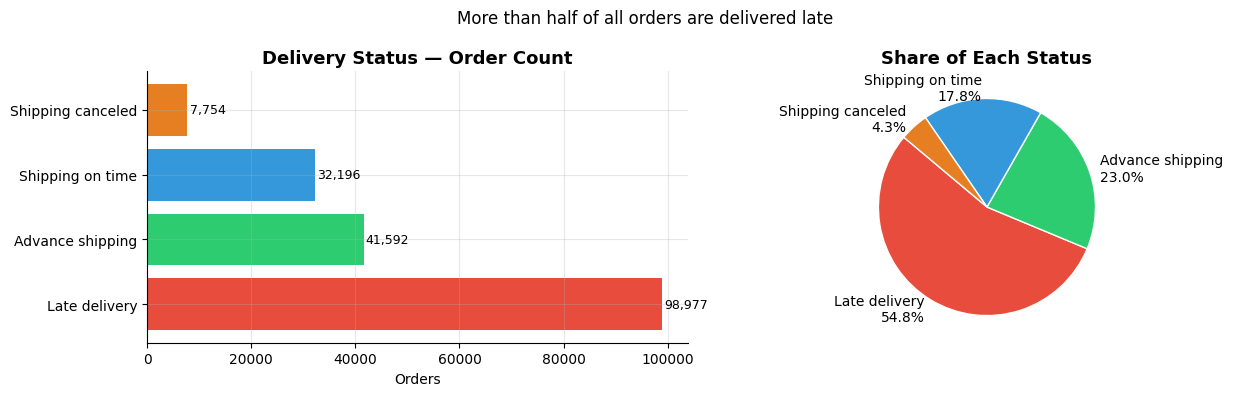

In [7]:
status  = df["delivery_status"].value_counts().sort("count", descending=True)
palette = {
    "Late delivery":    "#e74c3c",
    "Advance shipping": "#2ecc71",
    "Shipping on time": "#3498db",
    "Shipping canceled":"#e67e22",
}
labels = status["delivery_status"].to_list()
counts = status["count"].to_list()
colors = [palette.get(l, "#95a5a6") for l in labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bars = ax1.barh(labels, counts, color=colors)
ax1.set_xlabel("Orders")
ax1.set_title("Delivery Status — Order Count")
for b in bars:
    ax1.text(b.get_width() + 400, b.get_y() + b.get_height() / 2,
             f"{b.get_width():,}", va="center", fontsize=9)

pcts = [c / sum(counts) * 100 for c in counts]
ax2.pie(counts, labels=[f"{l}\n{p:.1f}%" for l, p in zip(labels, pcts)],
        colors=colors, startangle=140, wedgeprops={"edgecolor": "white"})
ax2.set_title("Share of Each Status")

plt.suptitle("More than half of all orders are delivered late", fontsize=12)
plt.tight_layout()
plt.show()

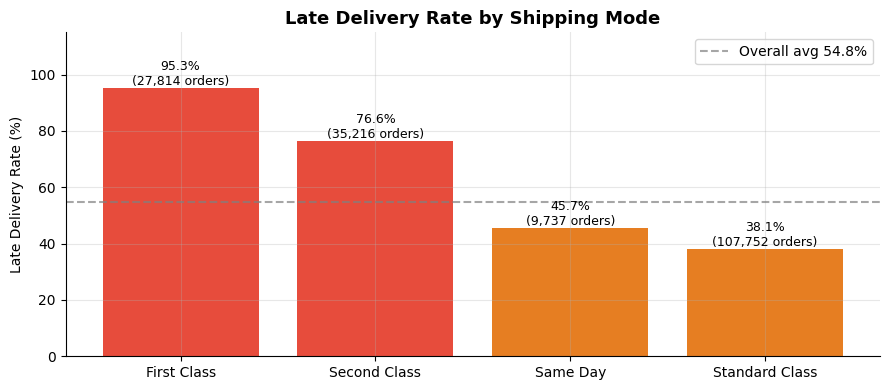

shape: (4, 5)
┌────────────────┬────────┬───────┬──────────────────┬──────────┐
│ shipping_mode  ┆ total  ┆ late  ┆ avg_overdue_days ┆ late_pct │
│ ---            ┆ ---    ┆ ---   ┆ ---              ┆ ---      │
│ str            ┆ u32    ┆ i32   ┆ f64              ┆ f64      │
╞════════════════╪════════╪═══════╪══════════════════╪══════════╡
│ First Class    ┆ 27814  ┆ 26513 ┆ 1.0              ┆ 95.3     │
│ Second Class   ┆ 35216  ┆ 26987 ┆ 1.99             ┆ 76.6     │
│ Same Day       ┆ 9737   ┆ 4454  ┆ 0.48             ┆ 45.7     │
│ Standard Class ┆ 107752 ┆ 41023 ┆ -0.0             ┆ 38.1     │
└────────────────┴────────┴───────┴──────────────────┴──────────┘


In [8]:
mode_stats = (
    df.group_by("shipping_mode")
    .agg([
        pl.col("order_id").count().alias("total"),
        pl.when(pl.col("delivery_status") == "Late delivery")
          .then(1).otherwise(0).sum().alias("late"),
        (pl.col("days_shipping_real") - pl.col("days_shipping_scheduled"))
          .mean().round(2).alias("avg_overdue_days"),
    ])
    .with_columns((pl.col("late") / pl.col("total") * 100).round(1).alias("late_pct"))
    .sort("late_pct", descending=True)
)

bar_colors = [
    "#e74c3c" if p > 50 else "#e67e22" if p > 30 else "#2ecc71"
    for p in mode_stats["late_pct"].to_list()
]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(mode_stats["shipping_mode"].to_list(),
              mode_stats["late_pct"].to_list(), color=bar_colors)
ax.axhline(54.8, color="gray", linestyle="--", alpha=0.7, label="Overall avg 54.8%")
ax.set_ylabel("Late Delivery Rate (%)")
ax.set_title("Late Delivery Rate by Shipping Mode")
ax.set_ylim(0, 115)
ax.legend()
for bar, row in zip(bars, mode_stats.iter_rows(named=True)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{row['late_pct']}%\n({row['total']:,} orders)", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
print(mode_stats)

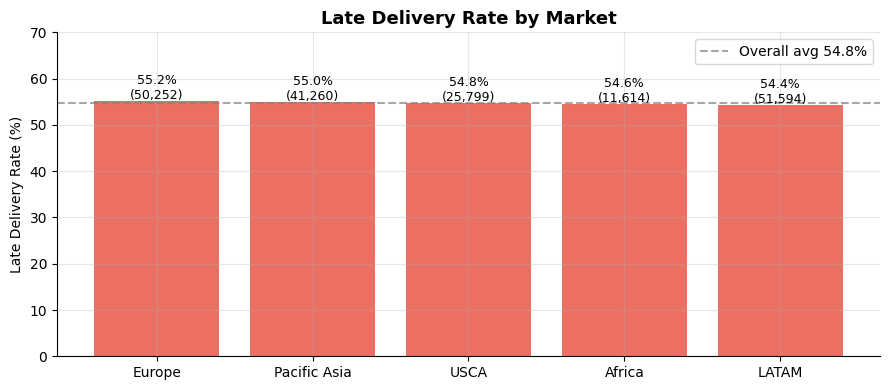

In [9]:
market_stats = (
    df.group_by("market")
    .agg([
        pl.col("order_id").count().alias("total"),
        pl.when(pl.col("delivery_status") == "Late delivery")
          .then(1).otherwise(0).sum().alias("late"),
    ])
    .with_columns((pl.col("late") / pl.col("total") * 100).round(1).alias("late_pct"))
    .sort("late_pct", descending=True)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(market_stats["market"].to_list(), market_stats["late_pct"].to_list(),
       color="#e74c3c", alpha=0.8)
ax.axhline(54.8, color="gray", linestyle="--", alpha=0.7, label="Overall avg 54.8%")
ax.set_ylabel("Late Delivery Rate (%)")
ax.set_title("Late Delivery Rate by Market")
ax.set_ylim(0, 70)
ax.legend()
for i, row in enumerate(market_stats.iter_rows(named=True)):
    ax.text(i, row["late_pct"] + 0.4,
            f"{row['late_pct']}%\n({row['total']:,})", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Business Problem #2 — Suspected Fraud

> **4,062 orders (2.3%) are flagged as suspected fraud**, exclusively via TRANSFER payment, concentrated in LATAM and Europe.

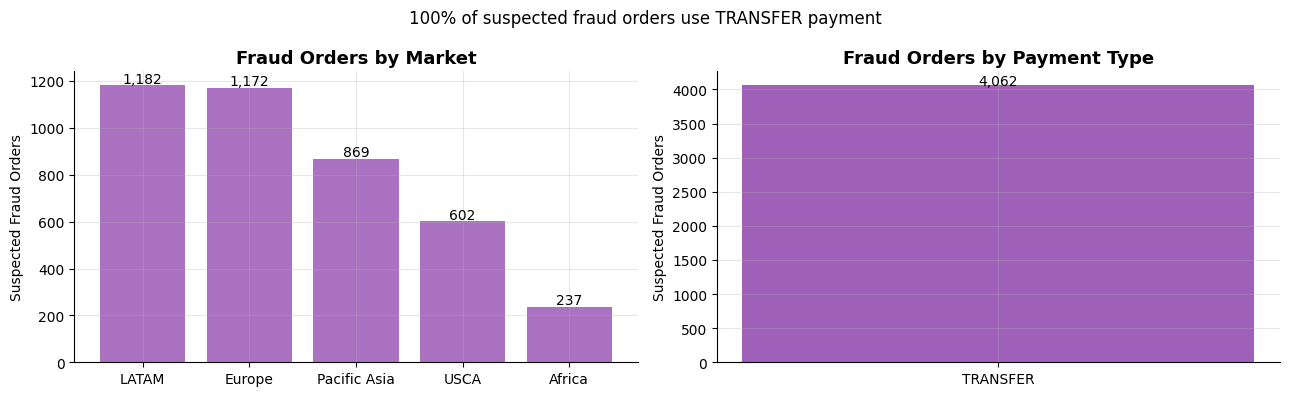

shape: (5, 4)
┌──────────────┬──────────────┬─────────────┬────────────┐
│ market       ┆ payment_type ┆ fraud_count ┆ avg_profit │
│ ---          ┆ ---          ┆ ---         ┆ ---        │
│ str          ┆ str          ┆ u32         ┆ f64        │
╞══════════════╪══════════════╪═════════════╪════════════╡
│ LATAM        ┆ TRANSFER     ┆ 1182        ┆ 22.54      │
│ Europe       ┆ TRANSFER     ┆ 1172        ┆ 20.33      │
│ Pacific Asia ┆ TRANSFER     ┆ 869         ┆ 17.8       │
│ USCA         ┆ TRANSFER     ┆ 602         ┆ 20.39      │
│ Africa       ┆ TRANSFER     ┆ 237         ┆ 29.19      │
└──────────────┴──────────────┴─────────────┴────────────┘


In [10]:
fraud_df = df.filter(pl.col("order_status") == "SUSPECTED_FRAUD")

m_totals = (fraud_df.group_by("market")
            .agg(pl.col("order_id").count().alias("n"))
            .sort("n", descending=True))
p_totals = (fraud_df.group_by("payment_type")
            .agg(pl.col("order_id").count().alias("n"))
            .sort("n", descending=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(m_totals["market"].to_list(), m_totals["n"].to_list(), color="#9b59b6", alpha=0.85)
ax1.set_title("Fraud Orders by Market")
ax1.set_ylabel("Suspected Fraud Orders")
for i, row in enumerate(m_totals.iter_rows(named=True)):
    ax1.text(i, row["n"] + 10, f"{row['n']:,}", ha="center", fontsize=10)

ax2.bar(p_totals["payment_type"].to_list(), p_totals["n"].to_list(), color="#8e44ad", alpha=0.85)
ax2.set_title("Fraud Orders by Payment Type")
ax2.set_ylabel("Suspected Fraud Orders")
for i, row in enumerate(p_totals.iter_rows(named=True)):
    ax2.text(i, row["n"] + 5, f"{row['n']:,}", ha="center", fontsize=10)

plt.suptitle("100% of suspected fraud orders use TRANSFER payment", fontsize=12)
plt.tight_layout()
plt.show()

detail = (
    fraud_df.group_by(["market", "payment_type"])
    .agg([pl.col("order_id").count().alias("fraud_count"),
          pl.col("order_profit_per_order").mean().round(2).alias("avg_profit")])
    .sort("fraud_count", descending=True)
)
print(detail)

## 6. Business Problem #3 — Profitability Issues

> **18.7% of orders are loss-making.** Uniform ~10% discounting across categories erodes margins without apparent targeting logic.

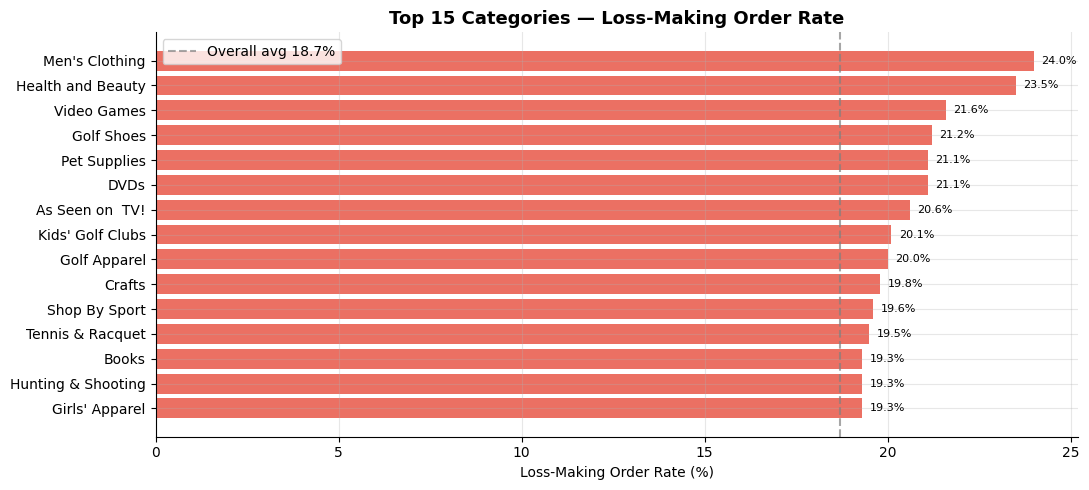

shape: (15, 6)
┌────────────────────┬──────────────┬─────────────┬──────────┬────────────────┬──────────────────┐
│ category_name      ┆ total_orders ┆ loss_orders ┆ loss_pct ┆ avg_margin_pct ┆ avg_discount_pct │
│ ---                ┆ ---          ┆ ---         ┆ ---      ┆ ---            ┆ ---              │
│ str                ┆ u32          ┆ i32         ┆ f64      ┆ f64            ┆ f64              │
╞════════════════════╪══════════════╪═════════════╪══════════╪════════════════╪══════════════════╡
│ Men's Clothing     ┆ 208          ┆ 50          ┆ 24.0     ┆ 5.3            ┆ 10.3             │
│ Health and Beauty  ┆ 362          ┆ 85          ┆ 23.5     ┆ 9.6            ┆ 10.1             │
│ Video Games        ┆ 838          ┆ 181         ┆ 21.6     ┆ 9.2            ┆ 10.2             │
│ Golf Shoes         ┆ 524          ┆ 111         ┆ 21.2     ┆ 12.1           ┆ 10.6             │
│ Pet Supplies       ┆ 492          ┆ 104         ┆ 21.1     ┆ 9.4            ┆ 10.2          

In [11]:
cat_profit = (
    df.group_by("category_name")
    .agg([
        pl.col("order_id").count().alias("total_orders"),
        pl.when(pl.col("order_profit_per_order") < 0).then(1).otherwise(0)
          .sum().alias("loss_orders"),
        pl.col("order_item_profit_ratio").mean().alias("avg_margin"),
        pl.col("order_item_discount_rate").mean().alias("avg_discount"),
    ])
    .with_columns([
        (pl.col("loss_orders") / pl.col("total_orders") * 100).round(1).alias("loss_pct"),
        (pl.col("avg_margin")   * 100).round(1).alias("avg_margin_pct"),
        (pl.col("avg_discount") * 100).round(1).alias("avg_discount_pct"),
    ])
    .sort("loss_pct", descending=True)
    .head(15)
)

names  = cat_profit["category_name"].to_list()
losses = cat_profit["loss_pct"].to_list()

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(names[::-1], losses[::-1], color="#e74c3c", alpha=0.8)
ax.axvline(18.7, color="gray", linestyle="--", alpha=0.7, label="Overall avg 18.7%")
ax.set_xlabel("Loss-Making Order Rate (%)")
ax.set_title("Top 15 Categories — Loss-Making Order Rate")
ax.legend()
for i, l in enumerate(losses[::-1]):
    ax.text(l + 0.2, i, f"{l}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print(cat_profit.select(["category_name", "total_orders", "loss_orders",
                          "loss_pct", "avg_margin_pct", "avg_discount_pct"]))

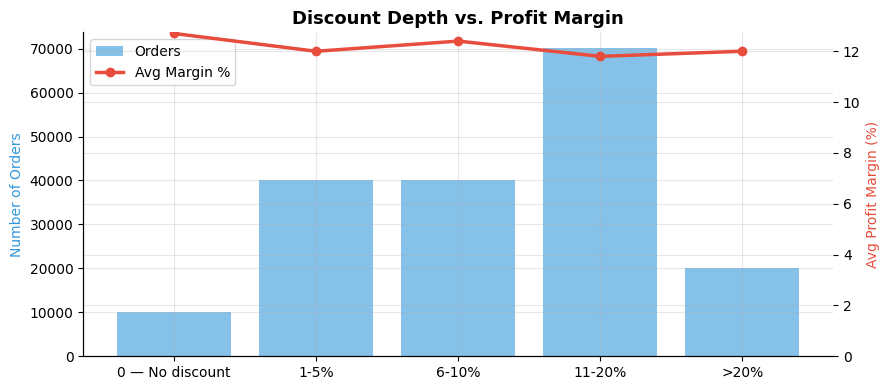

shape: (5, 4)
┌─────────────────┬────────┬────────────────┬─────────────┐
│ discount_bucket ┆ orders ┆ avg_margin_pct ┆ loss_orders │
│ ---             ┆ ---    ┆ ---            ┆ ---         │
│ str             ┆ u32    ┆ f64            ┆ i32         │
╞═════════════════╪════════╪════════════════╪═════════════╡
│ 0 — No discount ┆ 10028  ┆ 12.7           ┆ 1843        │
│ 1-5%            ┆ 40114  ┆ 12.0           ┆ 7496        │
│ 6-10%           ┆ 40116  ┆ 12.4           ┆ 7395        │
│ 11-20%          ┆ 70203  ┆ 11.8           ┆ 13233       │
│ >20%            ┆ 20058  ┆ 12.0           ┆ 3817        │
└─────────────────┴────────┴────────────────┴─────────────┘


In [16]:
bucket_order = {"0 — No discount": 0, "1-5%": 1, "6-10%": 2, "11-20%": 3, ">20%": 4}

discount_stats = (
    df.with_columns(
        pl.when(pl.col("order_item_discount_rate") == 0).then(pl.lit("0 — No discount"))
        .when(pl.col("order_item_discount_rate") <= 0.05).then(pl.lit("1-5%"))
        .when(pl.col("order_item_discount_rate") <= 0.10).then(pl.lit("6-10%"))
        .when(pl.col("order_item_discount_rate") <= 0.20).then(pl.lit("11-20%"))
        .otherwise(pl.lit(">20%"))
        .alias("discount_bucket")
    )
    .group_by("discount_bucket")
    .agg([
        pl.col("order_id").count().alias("orders"),
        (pl.col("order_item_profit_ratio").mean() * 100).round(1).alias("avg_margin_pct"),
        pl.when(pl.col("order_profit_per_order") < 0).then(1).otherwise(0)
          .sum().alias("loss_orders"),
    ])
    .with_columns(
        pl.col("discount_bucket")
        .map_elements(lambda x: bucket_order.get(x, 99), return_dtype=pl.Int32)
        .alias("_sort")
    )
    .sort("_sort").drop("_sort")
)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
buckets = discount_stats["discount_bucket"].to_list()
orders  = discount_stats["orders"].to_list()
margins = discount_stats["avg_margin_pct"].to_list()

ax1.bar(buckets, orders, color="#3498db", alpha=0.6, label="Orders")
ax2.plot(buckets, margins, color="#e74c3c", marker="o", linewidth=2.5, label="Avg Margin %")
ax1.set_ylabel("Number of Orders", color="#3498db")
ax2.set_ylabel("Avg Profit Margin (%)", color="#e74c3c")
ax1.set_title("Discount Depth vs. Profit Margin")
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
plt.tight_layout()
plt.show()
print(discount_stats)

## 7. Business Problem #4 — Cancellations & Stuck Orders

> **33.3% of orders stuck in PENDING/PENDING_PAYMENT** and **2% canceled** — likely pointing to payment gateway or fulfillment failures.

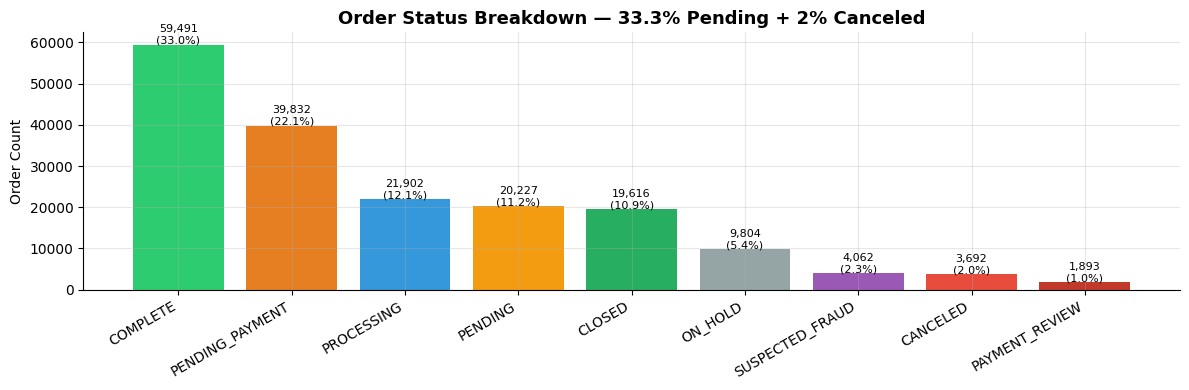

In [13]:
order_stats = (
    df.group_by("order_status")
    .agg(pl.col("order_id").count().alias("count"))
    .with_columns((pl.col("count") / df.height * 100).round(1).alias("pct"))
    .sort("count", descending=True)
)

palette = {
    "COMPLETE": "#2ecc71", "CLOSED": "#27ae60",
    "PENDING_PAYMENT": "#e67e22", "PENDING": "#f39c12",
    "PROCESSING": "#3498db", "ON_HOLD": "#95a5a6",
    "SUSPECTED_FRAUD": "#9b59b6", "CANCELED": "#e74c3c",
    "PAYMENT_REVIEW": "#c0392b",
}
colors = [palette.get(s, "#bdc3c7") for s in order_stats["order_status"].to_list()]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(order_stats["order_status"].to_list(),
              order_stats["count"].to_list(), color=colors)
ax.set_ylabel("Order Count")
ax.set_title("Order Status Breakdown — 33.3% Pending + 2% Canceled")
plt.xticks(rotation=30, ha="right")
for bar, row in zip(bars, order_stats.iter_rows(named=True)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
            f"{row['count']:,}\n({row['pct']}%)", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Sales Performance

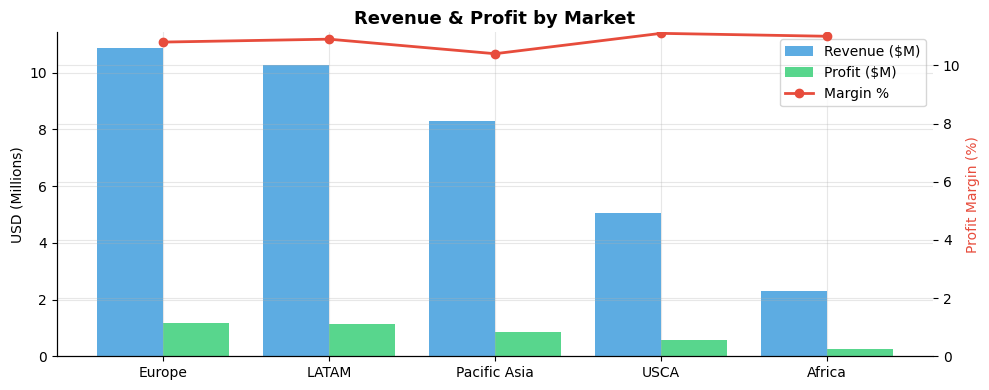

shape: (5, 5)
┌──────────────┬────────┬─────────────┬────────────┬────────────┐
│ market       ┆ orders ┆ revenue     ┆ profit     ┆ margin_pct │
│ ---          ┆ ---    ┆ ---         ┆ ---        ┆ ---        │
│ str          ┆ u32    ┆ f64         ┆ f64        ┆ f64        │
╞══════════════╪════════╪═════════════╪════════════╪════════════╡
│ Europe       ┆ 18561  ┆ 1.0872397e7 ┆ 1.169443e6 ┆ 10.8       │
│ LATAM        ┆ 17181  ┆ 1.0277613e7 ┆ 1.123322e6 ┆ 10.9       │
│ Pacific Asia ┆ 17577  ┆ 8.273744e6  ┆ 857753.0   ┆ 10.4       │
│ USCA         ┆ 8579   ┆ 5.066529e6  ┆ 564314.0   ┆ 11.1       │
│ Africa       ┆ 3854   ┆ 2.294453e6  ┆ 252071.0   ┆ 11.0       │
└──────────────┴────────┴─────────────┴────────────┴────────────┘


In [15]:
market_rev = (
    df.group_by("market")
    .agg([
        pl.col("order_id").n_unique().alias("orders"),
        pl.col("sales").sum().round(0).alias("revenue"),
        pl.col("order_profit_per_order").sum().round(0).alias("profit"),
    ])
    .with_columns((pl.col("profit") / pl.col("revenue") * 100).round(1).alias("margin_pct"))
    .sort("revenue", descending=True)
)

markets  = market_rev["market"].to_list()
revenues = [v / 1e6 for v in market_rev["revenue"].to_list()]
profits  = [v / 1e6 for v in market_rev["profit"].to_list()]
margins  = market_rev["margin_pct"].to_list()
x = list(range(len(markets)))

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar([i - 0.2 for i in x], revenues, width=0.4, color="#3498db", alpha=0.8, label="Revenue ($M)")
ax1.bar([i + 0.2 for i in x], profits,  width=0.4, color="#2ecc71", alpha=0.8, label="Profit ($M)")
ax2.plot(x, margins, color="#e74c3c", marker="o", linewidth=2, label="Margin %")
ax1.set_xticks(x)
ax1.set_xticklabels(markets)
ax1.set_ylabel("USD (Millions)")
ax2.set_ylabel("Profit Margin (%)", color="#e74c3c")
ax1.set_title("Revenue & Profit by Market")
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2)
plt.tight_layout()
plt.show()
print(market_rev)

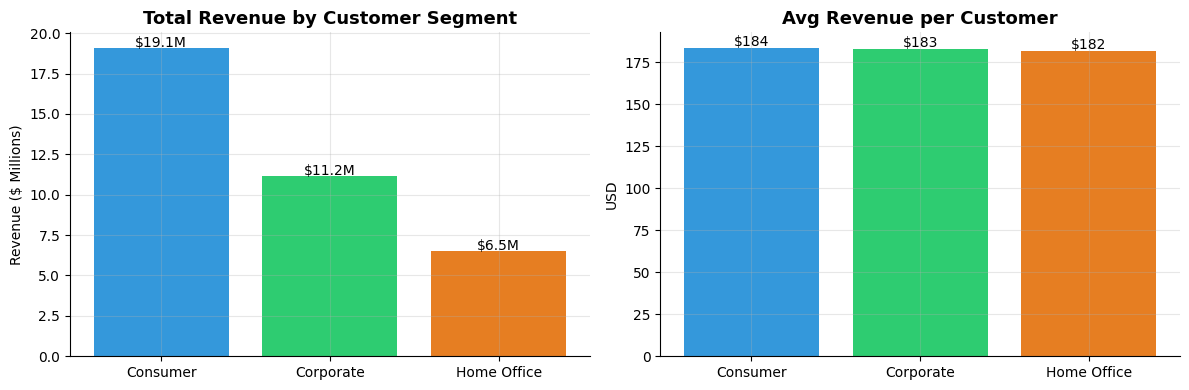

shape: (3, 5)
┌──────────────────┬───────────┬────────┬─────────────┬──────────────────────────┐
│ customer_segment ┆ customers ┆ orders ┆ revenue     ┆ avg_revenue_per_customer │
│ ---              ┆ ---       ┆ ---    ┆ ---         ┆ ---                      │
│ str              ┆ u32       ┆ u32    ┆ f64         ┆ f64                      │
╞══════════════════╪═══════════╪════════╪═════════════╪══════════════════════════╡
│ Consumer         ┆ 10695     ┆ 34119  ┆ 1.909579e7  ┆ 183.57                   │
│ Corporate        ┆ 6239      ┆ 19856  ┆ 1.1168407e7 ┆ 183.08                   │
│ Home Office      ┆ 3718      ┆ 11777  ┆ 6.520538e6  ┆ 181.82                   │
└──────────────────┴───────────┴────────┴─────────────┴──────────────────────────┘


In [17]:
seg = (
    df.group_by("customer_segment")
    .agg([
        pl.col("customer_id").n_unique().alias("customers"),
        pl.col("order_id").n_unique().alias("orders"),
        pl.col("sales").sum().round(0).alias("revenue"),
        pl.col("sales_per_customer").mean().round(2).alias("avg_revenue_per_customer"),
    ])
    .sort("revenue", descending=True)
)

segments = seg["customer_segment"].to_list()
revenues = [v / 1e6 for v in seg["revenue"].to_list()]
avgs     = seg["avg_revenue_per_customer"].to_list()
seg_colors = ["#3498db", "#2ecc71", "#e67e22"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(segments, revenues, color=seg_colors)
ax1.set_title("Total Revenue by Customer Segment")
ax1.set_ylabel("Revenue ($ Millions)")
for i, v in enumerate(revenues):
    ax1.text(i, v + 0.05, f"${v:.1f}M", ha="center", fontsize=10)

ax2.bar(segments, avgs, color=seg_colors)
ax2.set_title("Avg Revenue per Customer")
ax2.set_ylabel("USD")
for i, v in enumerate(avgs):
    ax2.text(i, v + 1, f"${v:.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()
print(seg)

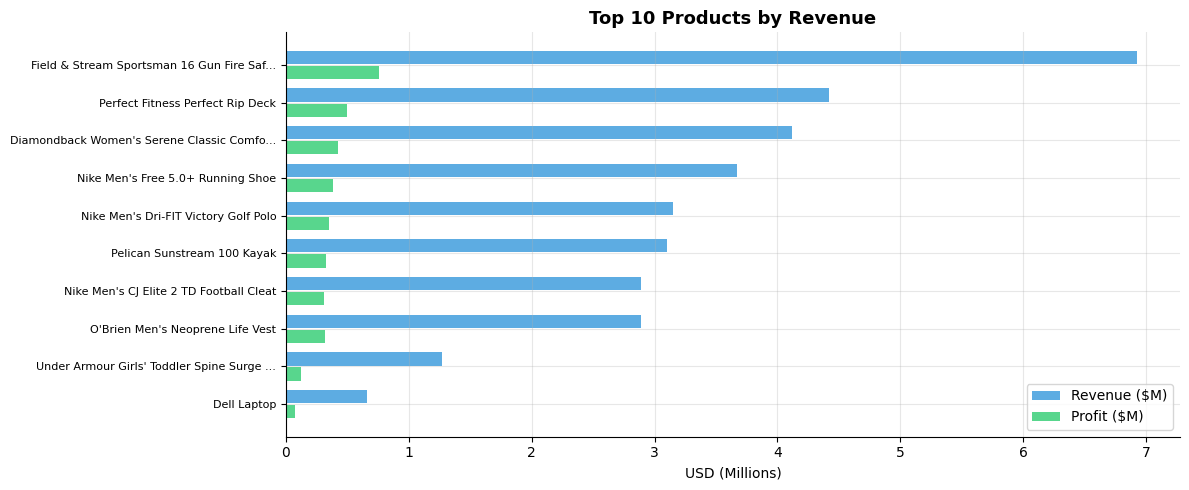

shape: (10, 5)
┌─────────────────────────────────┬────────┬────────────┬──────────┬────────────┐
│ product_name                    ┆ orders ┆ revenue    ┆ profit   ┆ margin_pct │
│ ---                             ┆ ---    ┆ ---        ┆ ---      ┆ ---        │
│ str                             ┆ u32    ┆ f64        ┆ f64      ┆ f64        │
╞═════════════════════════════════╪════════╪════════════╪══════════╪════════════╡
│ Field & Stream Sportsman 16 Gu… ┆ 17325  ┆ 6.929654e6 ┆ 756221.0 ┆ 10.9       │
│ Perfect Fitness Perfect Rip De… ┆ 24515  ┆ 4.421143e6 ┆ 493828.0 ┆ 11.2       │
│ Diamondback Women's Serene Cla… ┆ 13729  ┆ 4.118426e6 ┆ 427456.0 ┆ 10.4       │
│ Nike Men's Free 5.0+ Running S… ┆ 12169  ┆ 3.667633e6 ┆ 379916.0 ┆ 10.4       │
│ Nike Men's Dri-FIT Victory Gol… ┆ 21035  ┆ 3.1478e6   ┆ 350421.0 ┆ 11.1       │
│ Pelican Sunstream 100 Kayak     ┆ 15500  ┆ 3.099845e6 ┆ 324076.0 ┆ 10.5       │
│ Nike Men's CJ Elite 2 TD Footb… ┆ 22246  ┆ 2.891758e6 ┆ 311903.0 ┆ 10.8       │
│

In [18]:
top_prods = (
    df.group_by("product_name")
    .agg([
        pl.col("order_id").count().alias("orders"),
        pl.col("sales").sum().round(0).alias("revenue"),
        pl.col("order_profit_per_order").sum().round(0).alias("profit"),
    ])
    .with_columns((pl.col("profit") / pl.col("revenue") * 100).round(1).alias("margin_pct"))
    .sort("revenue", descending=True)
    .head(10)
)

names    = [n[:40] + "..." if len(n) > 40 else n for n in top_prods["product_name"].to_list()]
revenues = [v / 1e6 for v in top_prods["revenue"].to_list()]
profits  = [v / 1e6 for v in top_prods["profit"].to_list()]
y = list(range(len(names)))

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh([i + 0.2 for i in y], revenues[::-1], height=0.35, color="#3498db", alpha=0.8, label="Revenue ($M)")
ax.barh([i - 0.2 for i in y], profits[::-1],  height=0.35, color="#2ecc71", alpha=0.8, label="Profit ($M)")
ax.set_yticks(y)
ax.set_yticklabels(names[::-1], fontsize=8)
ax.set_xlabel("USD (Millions)")
ax.set_title("Top 10 Products by Revenue")
ax.legend()
plt.tight_layout()
plt.show()
print(top_prods.select(["product_name", "orders", "revenue", "profit", "margin_pct"]))